# Lecture 20 - Hard-Margin SVM Optimization with Lagrange Multipliers

From previous lecture, we designed the objective function for **hard-margin SVM**. In hard-margin SVM, we assume classes are linearly separable in the space defined by $\phi(x)$.

\begin{align*}
&\arg_{w,b}\min \frac{1}{2} \Vert w\Vert^2 \\
& \text{subject to } t_ny(x_n) \geq 1
\end{align*}

where $y(x_n)=w^T\phi(x_n)+b$ is the discriminant function.

---

In order to solve this constrained optimization problem, we introduce *Lagrange multipliers* $a_n \geq 0$, with one multiplier an for each of the constraints, giving the Lagrangian function

$$L(w,b,a) = \frac{1}{2}\Vert w\Vert^2 - \sum_{n=1}^N a_n \left(t_n(w^T\phi(x_n)+b) - 1\right)$$

* Note the minus sign in front of the Lagrange multiplier term, because we are minimizing with respect to $w$ and $b$, and maximizing with respect to $a$. 

Setting the derivatives of $L(w, b, a)$ with respect to $w$ and $b$ equal to zero, we obtain the following two conditions:

$$w = \sum_{n=1}^N a_nt_n\phi(x_n)$$

$$ 0 = \sum_{n=1}^N a_nt_n$$

Eliminating $w$ and $b$ from $L(w, b, a)$ using these conditions then gives the *dual representation* of the maximum margin problem in which we maximize

\begin{align*}
\tilde{L}(a) &= \frac{1}{2}\left(\sum_{n=1}^N a_nt_n\phi(x_n) \right)^T\left(\sum_{n=1}^N a_nt_n\phi(x_n) \right) - \sum_{n=1}^N a_n \left(t_n\left(\left(\sum_{m=1}^N a_mt_m\phi(x_m)\right)^T\phi(x_n)+b\right) - 1\right)\\
&= \frac{1}{2} \sum_{n=1}^N\sum_{m=1}^N a_n a_m t_n t_m \phi(x_n)^T\phi(x_m) - \sum_{n=1}^N\sum_{m=1}^N a_n a_m t_n t_m \phi(x_n)^T\phi(x_m) - \sum_{n=1}^N a_n t_n b + \sum_{n=1}^N a_n\\
&= -\frac{1}{2} \sum_{n=1}^N\sum_{m=1}^N a_n a_m t_n t_m \phi(x_n)^T\phi(x_m) - b \sum_{n=1}^N a_n t_n + \sum_{n=1}^N a_n\\
&=\sum_{n=1}^N a_n - \frac{1}{2}\sum_{n=1}^N\sum_{m=1}^N a_n a_m t_n t_m K(x_n, x_m)
\end{align*}

where we used $\sum_{n=1}^N a_nt_n=0$. We also have the constraints:

$$a_n \geq 0, n=1,2,\dots, N$$

$$\sum_{n=1}^N a_nt_n = 0$$

Here the kernel function is defined by $K(x,y) = \phi(x)^T \phi(y)$. 

* This takes the form of a quadratic programming problem in which we optimize a quadratic function of a subject to a set of inequality constraints.

* The solution to a quadratic programming problem in $M$ variables in general has computational complexity that is $O(M^3)$. In going to the dual formulation we have turned the original optimization problem into the dual problem, which has $N$ variables. 
    * For a fixed set of basis functions whose number $M$ is smaller than the number $N$ of data points, the move to the dual problem appears disadvantageous. However, it allows the model to be reformulated using kernels, and so the maximum margin classifier can be applied efficiently to feature spaces whose dimensionality exceeds the number of data points, including infinite feature spaces. 
    * The kernel formulation also makes clear the role of the constraint that the kernel function $K(x,y)$ be positive definite, because this ensures that the Lagrangian function $\tilde{L}(a)$ is bounded below, giving rise to a well defined optimization problem.

---

# Kernel Function

An inner product is a function that takes two inputs from a space and outputs a single value by combining the inputs, and is expressed as $\langle\mathbf{x},\mathbf{y}\rangle$. For example, the dot product between two vectors: $\langle\mathbf{x},\mathbf{y}\rangle = \mathbf{x}\cdot\mathbf{y} = \sum_{i=1}^d x_iy_i$. 

A **kernel** is a function that calculates the inner product in an enlarged feature space using only values from the original feature space, and is expressed as $K(\mathbf{x},\mathbf{y})$. For example, using the mapping $\phi(\mathbf{x})$ below,

\begin{align*}
\phi: \mathbb{R}^2 &\longrightarrow \mathbb{R}^3 \\
[x_1,x_2] &\longmapsto [x_1^2, \sqrt{2}x_1x_2, x_2^2]
\end{align*}

the related kernel for the dot product in the enlarged space is

\begin{align*}
K((x_1,x_2),(y_1,y_2)) &= \langle(x_1^2,\sqrt{2}x_1x_2,x_2^2),(y_1^2,\sqrt{2}y_1y_2,y_2^2)\rangle\\
&= x_1^2x_2^2 + 2x_1x_2y_1y_2 + y_1^2y_2^2\\
&= (x_1x_2 + y_1y_2)^2
\end{align*}

* The inner product of two instances is calculated in the feature space.
* A mapping sends these instances to the enlarged space. $[x_1,x_2]$ maps to $[x_1^2, \sqrt{2}x_1x_2, x_2^2]$ and $[y_1,y_2]$ maps to $[y_1^2, \sqrt{2}y_1y_2, y_2^2]$.
* The inner product between the instances is calculated in the enlarged space.
* The kernel, $K(\mathbf{x},\mathbf{y})$, encodes this mapping and then the inner product. Sometimes the kernel is calculated directly from the feature space.

Kernels used in support vector classification typically measure the similarity or distance between instances. The most commonly used kernels for support vector classifiers are listed below.

### Common Kernels

1. **Polynomial kernel**

$$K(\mathbf{x},\mathbf{y}) = (1 + \langle\mathbf{x},\mathbf{y}\rangle)^d$$

Instances are mapped into an enlarged space of polynomial powers similar to the example at the section's start. The decision boundary will curve some.

2. **Radial Basis Function (RBF) kernel**

$$K(\mathbf{x},\mathbf{y}) = e^{-\gamma \Vert\mathbf{x}-\mathbf{y}\Vert^2}$$

Instances are mapped into an enlarged space where each dimension is related to the distance from one instance. An instance that is closer to a dimension's instance in the feature space will have a larger value. The decision boundary will curve around clusters of instances of the same class.

3. **Sigmoid kernel**

$$K(\mathbf{x},\mathbf{y}) = \text{tanh}(\gamma\langle\mathbf{x},\mathbf{y}\rangle + 1)$$

The sigmoid function is used due to a similar response to biological neurons. The sigmoid function restricts the gains from large inputs to between -1 and 1, reducing the spread of values in the enlarged space.

## The Kernel Trick

The kernel trick uses a kernel in place of the inner product. A support vector machine (SVM) is a support vector classifier that utilizes the kernel trick.

---

In order to classify new data points using the trained model, we evaluate the sign of $y(x) = w^T\phi(x) + b$. This can be expressed in terms of the parameters $\{a_n\}$ and the kernel function by substituting for $w$ to give

$$y(x) = \sum_{n=1}^N a_n t_n K(x,x_n) + b$$

* A constrained optimization of this form satisfies the Karush-Kuhn-Tucker (KKT) conditions, which in this case require that the following three properties hold

\begin{align*}
& a_n \geq 0 \\
& t_n y(x_n) - 1 \geq 0 \\
& a_n \left(t_n y(x_n) - 1\right) = 0
\end{align*}

Thus for every data point, either $a_n = 0$ or $t_n y(x_n) = 1$. 
* Any data point for which $a_n = 0$ will not appear in the sum of $y(x)$ and hence plays no role in making predictions for new data points. 

* The remaining data points are called **support vectors**, and because they satisfy $t_n y(x_n) = 1$, they correspond to points that lie on the maximum margin hyperplanes in feature space. 

* Once the model is trained, a significant proportion of the data points can be discarded and only the support vectors retained!

Having solved the quadratic programming problem and found a value for $a$, we can then determine the value of the threshold parameter $b$ by noting that any support vector $x_n$ satisfies $t_n y(x_n) = 1$.

$$t_n \left(\sum_{m\in S}a_m t_m K(x_n,x_m) + b\right) = 1$$

where $S$ denotes the set of indices of the support vectors. Although we can solve this equation for $b$ using an arbitrarily chosen support vector $x_n$, a numerically more stable solution is obtained by first multiplying through by $t_n$, making use of $t_n^2 = 1$, and then averaging these equations over all support vectors and solving for $b$ to give

$$b = \frac{1}{N_S} \sum_{n\in S}\left(t_n - \sum_{m\in S}a_m t_m K(x_n, x_m)\right)$$

where $N_S$ is the total number of support vectors.

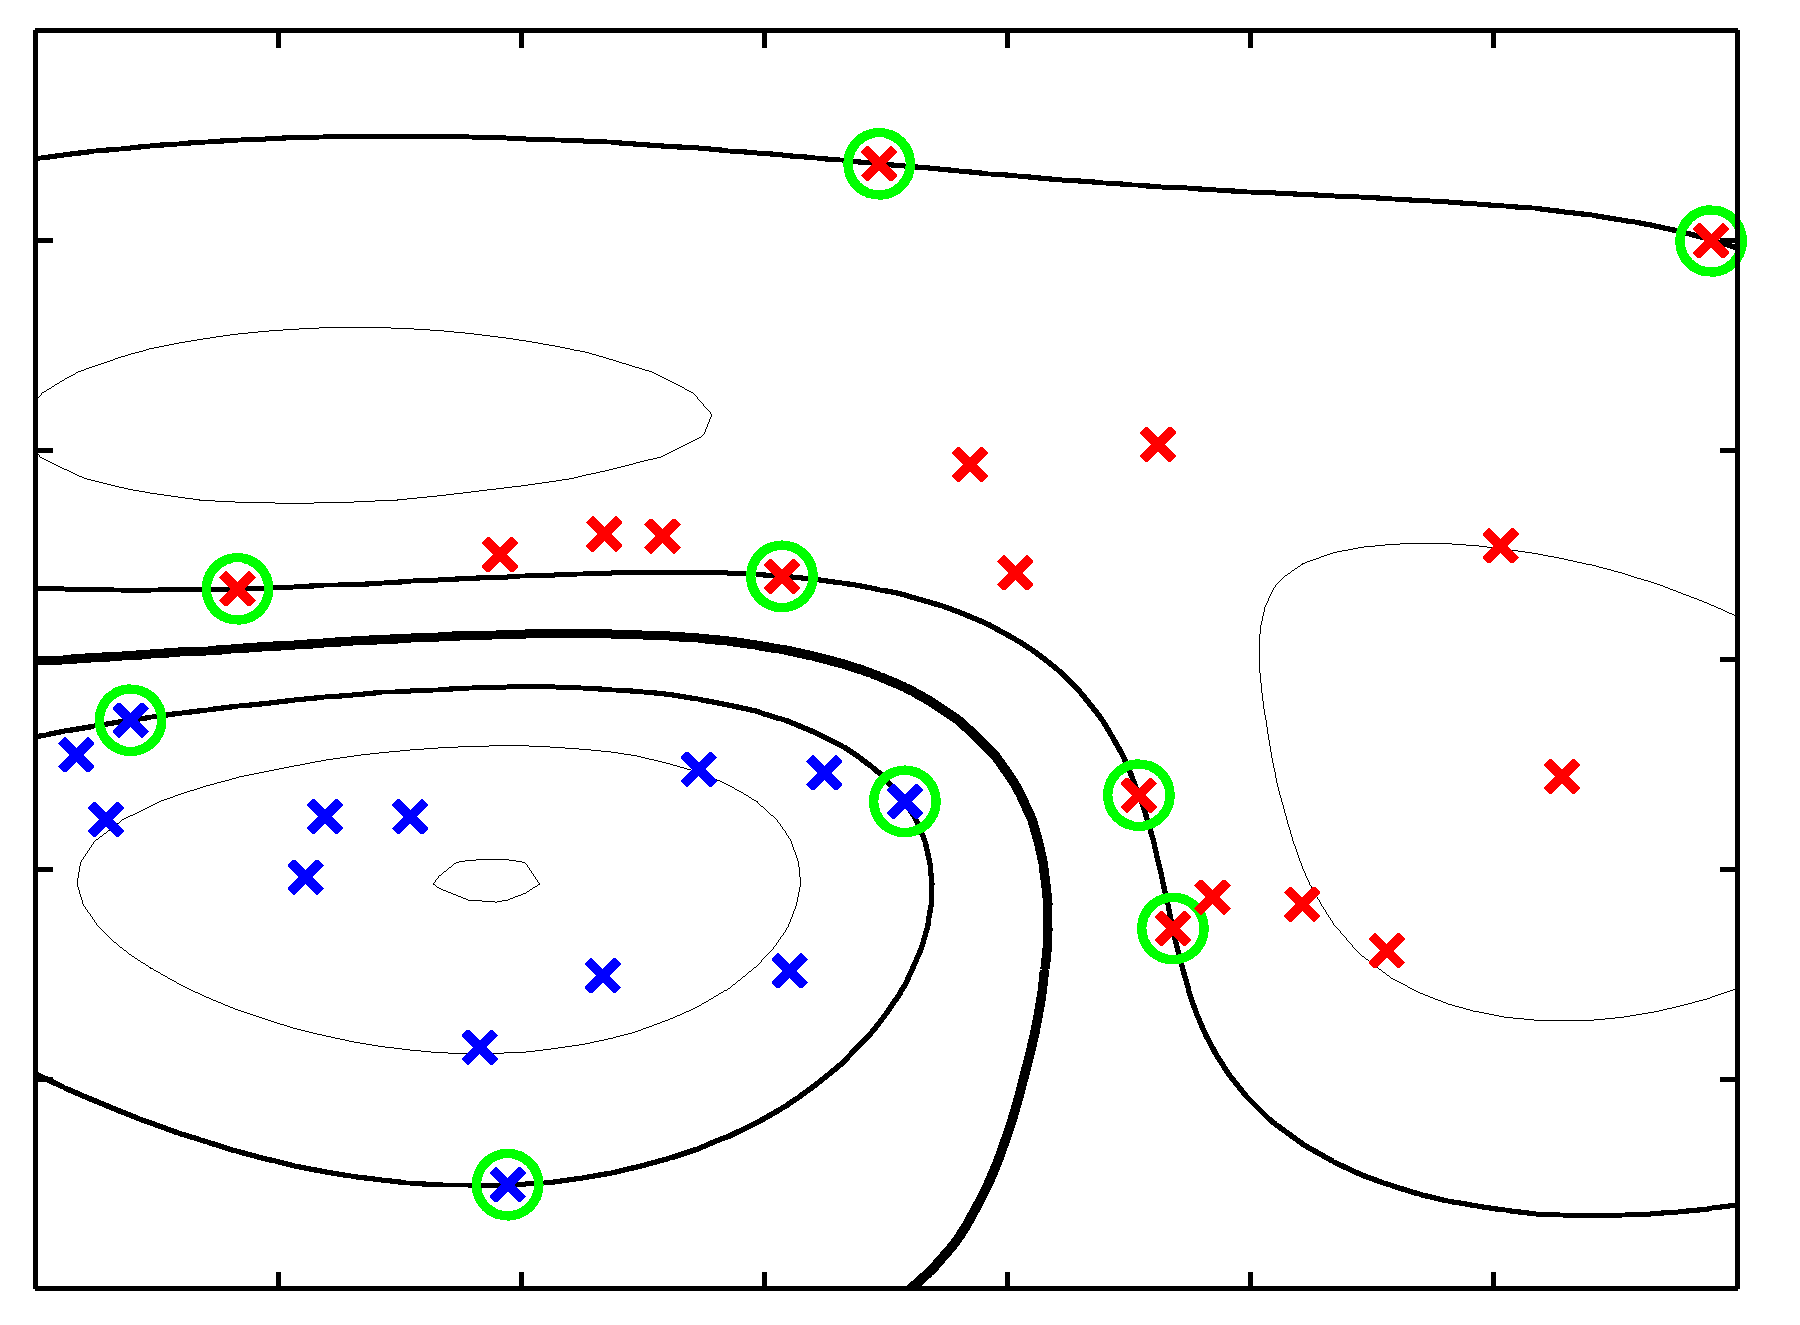

In [1]:
from IPython.display import Image
Image("figures/Figure7.2.png", width=400)
#Source: Bishop textbook

Although the data set is not linearly separable in the two-dimensional data space $x$, it is linearly separable in the nonlinear feature space defined implicitly by the nonlinear kernel function. Thus the training data points are perfectly separated in the original data space.

This example also provides a geometrical insight into the origin of sparsity in the SVM. The maximum margin hyperplane is defined by the location of the support vectors. Other data points can be moved around freely (so long as they remain outside the margin region) without changing the decision boundary, and so the solution will be independent of such data points.

---

## Code Example of Hard-Margin SVM

Linearly-separable classes in the feature space spanned by the transformation $\phi(x)$ may form a non-linear decision boundary in the input space.

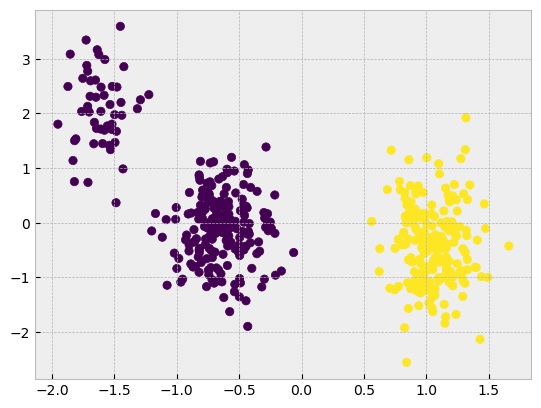

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
from sklearn.preprocessing import StandardScaler

X = np.load('data.npy')
t = np.load('labels.npy')

scaler = StandardScaler()
X=scaler.fit_transform(X)
plt.scatter(X[:, 0], X[:, 1], c=t);

In [2]:
from sklearn.svm import SVC # "Support vector classifier"

In [3]:
svm = SVC(kernel='linear', C=1E6)
svm.fit(X, t)

SVC(C=1000000.0, kernel='linear')

In [4]:
#source: https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

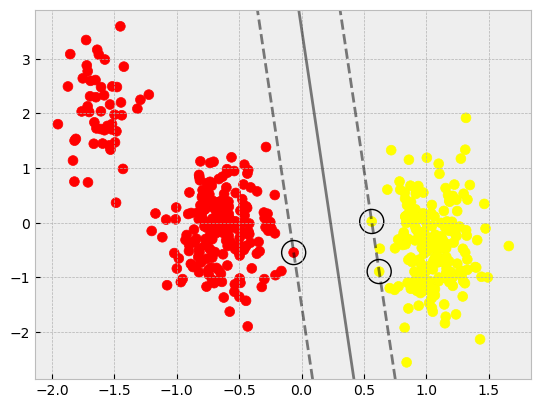

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
plot_svc_decision_function(svm);

In [6]:
svm.support_vectors_

array([[-0.06343854, -0.5479684 ],
       [ 0.56176003,  0.02103463],
       [ 0.62170369, -0.89592457]])

---

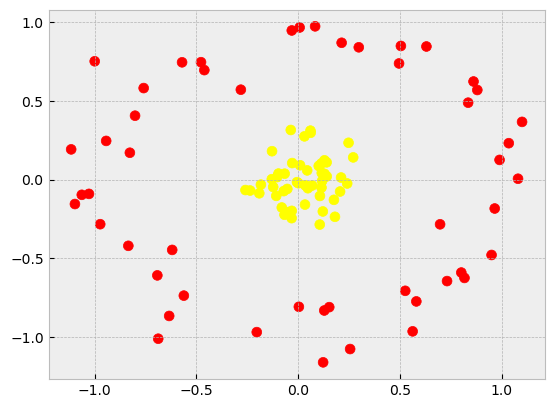

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

X, t = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:,0], X[:,1], c=t, s=50, cmap='autumn');

X_train, X_test, t_train, t_test = train_test_split(X, t,
                                                   test_size=0.3,
                                                   stratify=t,
                                                   random_state=0)

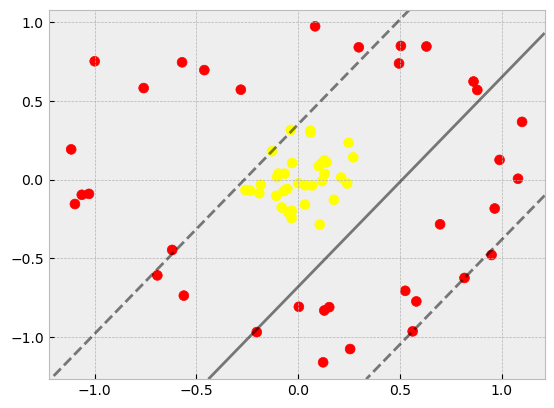

In [8]:
clf = SVC(kernel='linear')
clf.fit(X_train, t_train)

plt.scatter(X_train[:, 0], X_train[:, 1], c=t_train, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [9]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X_train, t_train)

SVC(C=1000000.0)

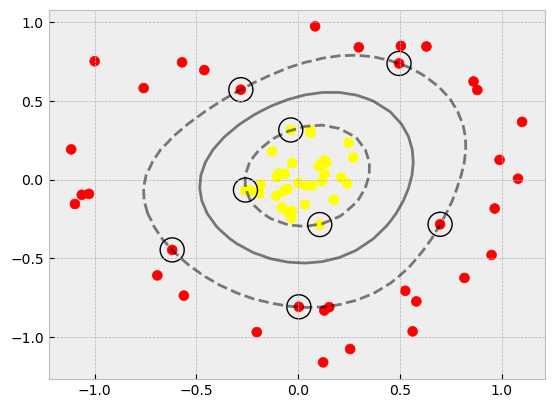

In [10]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_train, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

In [11]:
clf.decision_function(X_test)

array([ 1.69427983, -1.46183765, -1.5139937 ,  1.63697066,  1.69813828,
       -1.34466456,  1.20903488, -1.69390673,  1.40978435,  1.27422966,
       -1.5260912 , -1.39228193, -2.04025004, -1.54084698,  1.73407047,
        1.4836533 , -1.71440703, -1.15221284, -1.26330278, -1.31405491,
        1.65978928,  1.68214911, -1.51600446,  1.05082345,  1.47788441,
        1.26102601,  1.70367909, -1.6546275 , -1.3947034 ,  1.55524217])

In [12]:
1*(clf.decision_function(X_test)>0)

array([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1])

In [13]:
y_test = clf.predict(X_test)
y_test

array([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1])

In [14]:
clf.score(X_test, t_test)

1.0

In [15]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(t_test, y_test))

[[15  0]
 [ 0 15]]


---

---
---
---